In [1]:
omega_m_marie = 0.2589 +- 0.0123
0.2594 +- 0.0074 #without expansion function (model-independent)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.optimize import curve_fit
import scipy.interpolate as interp
import camb
# from camb import model, initialpower
import sys
sys.path.append("/home/steven/thesis/mod")
from model_independent import model_independent
from model_independent import Growth_Factor

In [11]:
k = np.loadtxt("../../inputs/k_pre_ext.txt")
x = np.logspace(np.log10(1),np.log10(20),200)
k

array([7.24847778e-05, 7.71946906e-05, 8.22106439e-05, 8.75525236e-05,
       9.32415078e-05, 9.93001505e-05, 1.05752471e-04, 1.12624051e-04,
       1.19942132e-04, 1.27735727e-04, 1.36035733e-04, 1.44875057e-04,
       1.54288743e-04, 1.64314110e-04, 1.74990905e-04, 1.86361457e-04,
       1.98470844e-04, 2.11367074e-04, 2.25101275e-04, 2.39727896e-04,
       2.55304925e-04, 2.71894117e-04, 2.89561242e-04, 3.08376340e-04,
       3.28414004e-04, 3.49753676e-04, 3.72479955e-04, 3.96682942e-04,
       4.22458589e-04, 4.49909085e-04, 4.79143259e-04, 5.10277009e-04,
       5.43433767e-04, 5.78744983e-04, 6.16350650e-04, 6.56399856e-04,
       6.99051378e-04, 7.44474309e-04, 7.92848729e-04, 8.44366420e-04,
       8.99231625e-04, 9.57661860e-04, 1.01988877e-03, 1.08615906e-03,
       1.15673546e-03, 1.23189777e-03, 1.31194397e-03, 1.39719141e-03,
       1.48797805e-03, 1.58466382e-03, 1.68763204e-03, 1.79729093e-03,
       1.91407522e-03, 2.03844792e-03, 2.17090210e-03, 2.31196288e-03,
      

In [2]:
a = np.loadtxt("a_bg.txt")
zd = np.loadtxt("z_distanceme.txt")
zm = np.loadtxt("z_matterme.txt")
k = np.loadtxt("k_hme.txt")
ells = np.loadtxt("ellsme.txt")
klin = np.loadtxt("k_h_lin.txt")
kpre = np.loadtxt("k_pre_ext.txt")

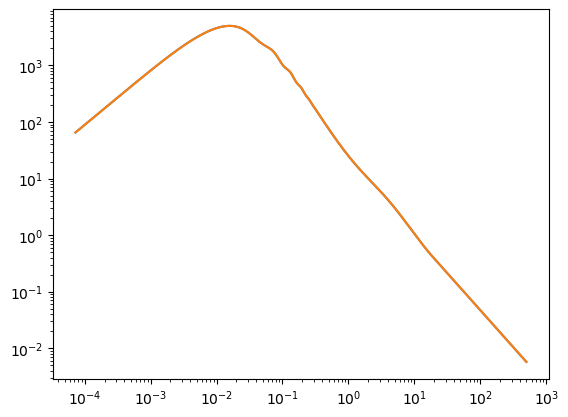

In [6]:
pm_ori = np.loadtxt("pm_nl_kids.txt")[-50]
pm =np.loadtxt("pm.txt")[-50]
plt.loglog(k,pm_ori)
plt.loglog(k,pm)

False
False
False
False


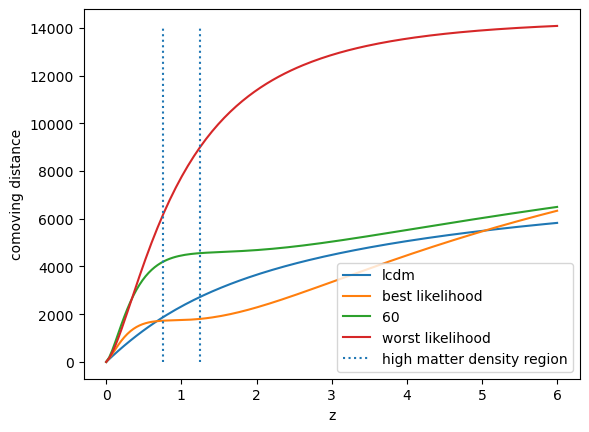

In [60]:
chibest = np.loadtxt("chi_best_like.txt")
chi60 = np.loadtxt("chi_like_60.txt")
chilcdm = np.loadtxt("chi_lcdm.txt")
chiworst = np.loadtxt("chi_worstlike.txt")
# chi_of_z_best = interp.InterpolatedUnivariateSpline(zd, chibest)
# chi_of_z_lcdm = interp.InterpolatedUnivariateSpline(zd, chilcdm)
# chi_of_z_60 = interp.InterpolatedUnivariateSpline(zd, chi60)
# chibest = chi_of_z_best(zd)
# chi60 = chi_of_z_60
# chilcdm = chi_of_z_lcdm
print(np.any(np.diff(chibest<0)))
print(np.any(np.diff(chilcdm<0)))
print(np.any(np.diff(chi60<0)))
print(np.any(np.diff(chiworst<0)))
plt.plot(zd,chilcdm,label='lcdm')
plt.plot(zd,chibest,label="best likelihood")
plt.plot(zd,chi60,label="60")
plt.plot(zd,chiworst,label="worst likelihood")
plt.vlines([0.75,1.25],[0,0],[14000,14000],linestyles='dotted',label="high matter density region")
plt.ylabel("comoving distance")
plt.xlabel("z")
plt.legend()

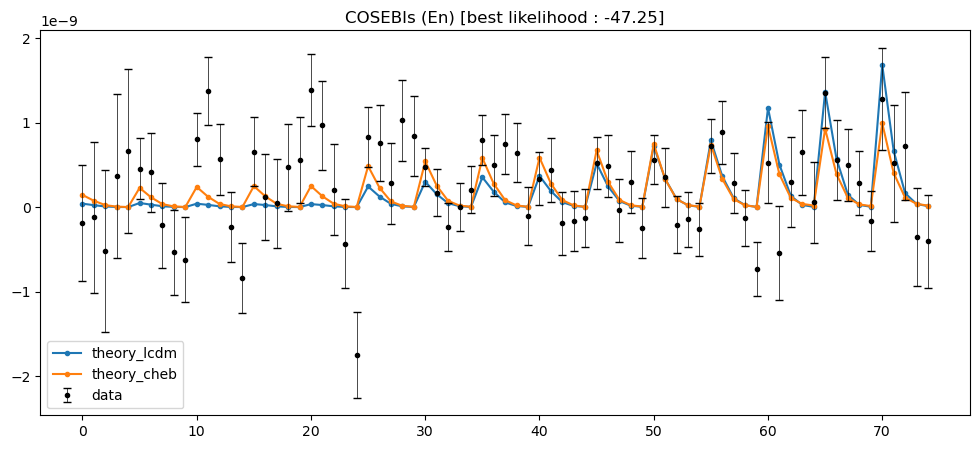

In [5]:
theory = np.loadtxt("data-theory_best_like_3.txt",skiprows=1)[:,1]
dt60 = np.loadtxt("data-theory_data60_theory60.txt")
cov60 = np.loadtxt("cov60.txt")
error = np.sqrt(np.diag(cov60))
plt.figure(figsize=(12,5))
plt.plot(dt60[:,1],label="theory_lcdm",marker = '.')
plt.plot(theory, label = "theory_cheb",marker='.')
# plt.plot(dt60[:,0], label = "data",marker = '.')
plt.errorbar(np.arange(len(dt60[:,0])),dt60[:,0],yerr=error, label="data", capsize=3, ecolor='black',elinewidth=0.5, fmt='o',linewidth = 0.5, markersize = 3, color = 'black')
plt.title("COSEBIs (En) [best likelihood : -47.25]")
plt.legend();


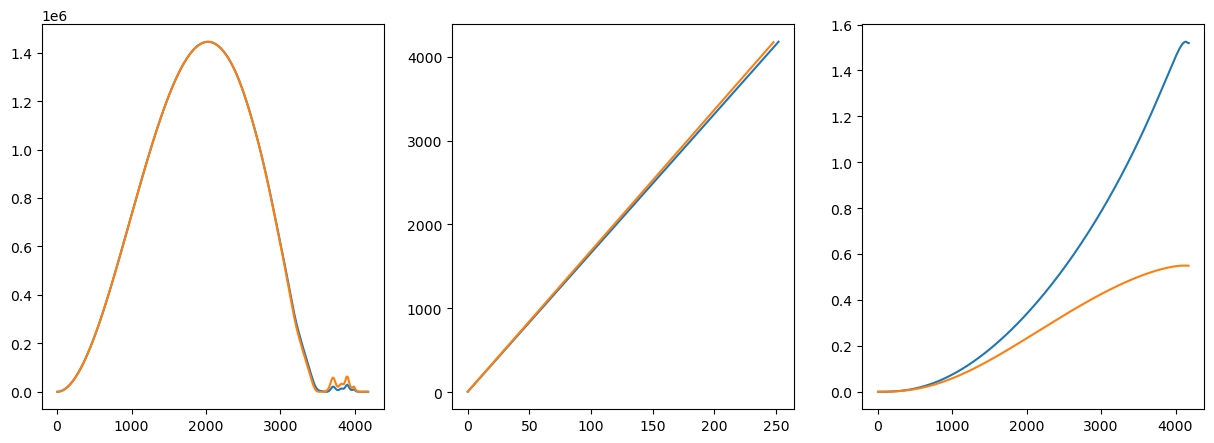

In [73]:
ell = -1
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(chi_val_z2[ell],k1k2_z2[ell])
plt.plot(chi_val_z6[ell],k1k2_z6[ell])
plt.subplot(1,3,2)
plt.plot(chi_val_z2[ell])
plt.plot(chi_val_z6[ell])
plt.subplot(1,3,3)
plt.plot(chi_val_z2[ell],pk_val_z2[ell])
plt.plot(chi_val_z6[ell],pk_val_z6[ell])

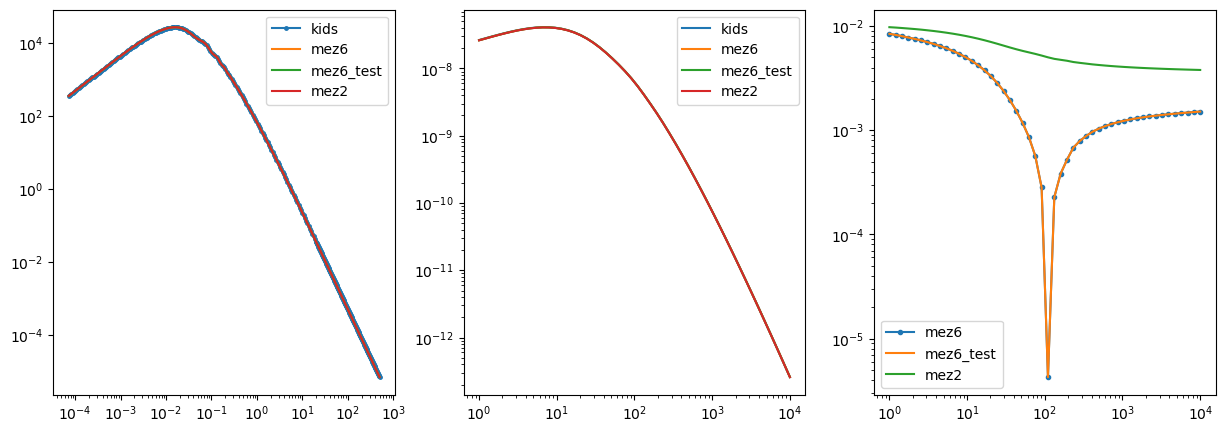

In [65]:
pm_kids = np.loadtxt("pm_lin_kids_ext.txt")
pm_mez6 = np.loadtxt("pm_me_z6.txt")
pm_mez2 = np.loadtxt("pm_me_z2.txt")
pm_mez6_test = np.loadtxt("pm_me_z6_test.txt")
cell_kids = np.loadtxt("c_ell_lcdm_5_5_60.txt")
cell_mez6 = np.loadtxt("c_ell_me_z6.txt")
cell_mez2 = np.loadtxt("c_ell_me_z2.txt")
cell_mez6_test = np.loadtxt("c_ell_me_z6_test.txt")
index = 0

err_me6 = np.abs((cell_mez6-cell_kids)/cell_kids)
err_me2 = np.abs((cell_mez2-cell_kids)/cell_kids)
err_me6_test = np.abs((cell_mez6_test-cell_kids)/cell_kids)


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.loglog(k,pm_kids[index],label="kids",marker='.',markersize = 5)
plt.loglog(k,pm_mez6[index],label="mez6")
plt.loglog(k,pm_mez6_test[index],label="mez6_test")
plt.loglog(k,pm_mez2[0],label="mez2")
plt.legend()

plt.subplot(1,3,2)
plt.loglog(ells,cell_kids,label="kids")
plt.loglog(ells,cell_mez6,label="mez6")
plt.loglog(ells,cell_mez6_test,label="mez6_test")
plt.loglog(ells,cell_mez2,label="mez2")
plt.legend()

plt.subplot(1,3,3)
plt.loglog(ells,err_me6,label="mez6",marker='.')
plt.loglog(ells,err_me6_test,label="mez6_test")
plt.loglog(ells,err_me2,label="mez2")
plt.legend()

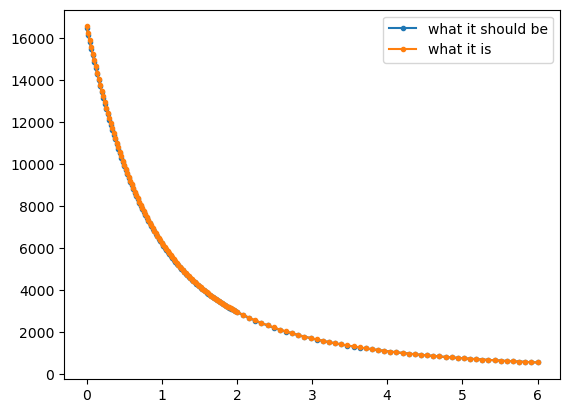

In [63]:
plt.plot(zm,pm_kids[:,100],marker='.',label="what it should be")
plt.plot(zm,pm_mez6[:,100],marker='.', label="what it is")
plt.legend()

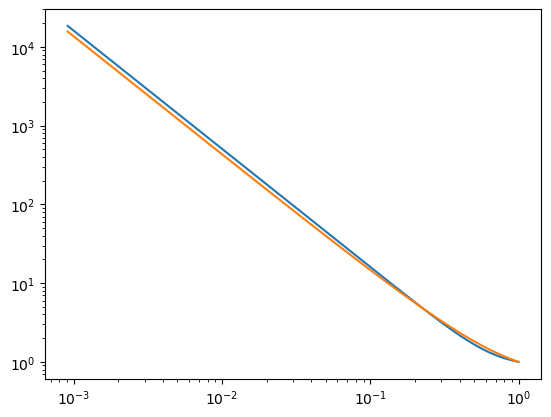

In [4]:
aaa = np.loadtxt("me_a_bg.txt")
expf = np.loadtxt("expf.txt")
lcdm = np.loadtxt("lcdm_expf.txt")

plt.loglog(aaa,lcdm)
plt.loglog(aaa,expf)

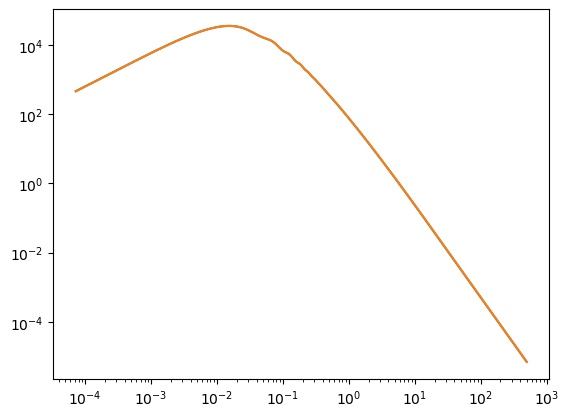

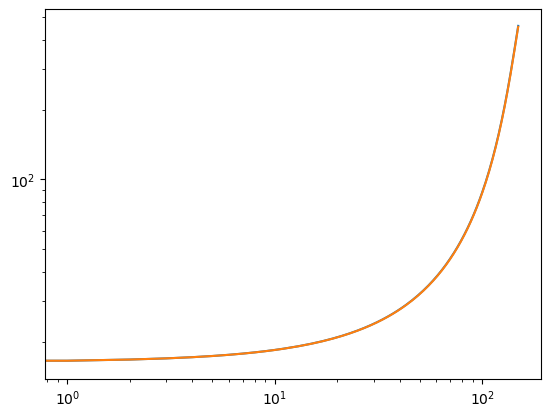

In [49]:
pm_kids = np.loadtxt("pm_lin_kids_nomid.txt")
pm_test = np.loadtxt("pm_test.txt")
plt.loglog(k,pm_kids[0])
plt.loglog(k,pm_test[0])
plt.show()

plt.loglog(pm_kids[::-1,0])
plt.loglog(pm_test[::-1,0])

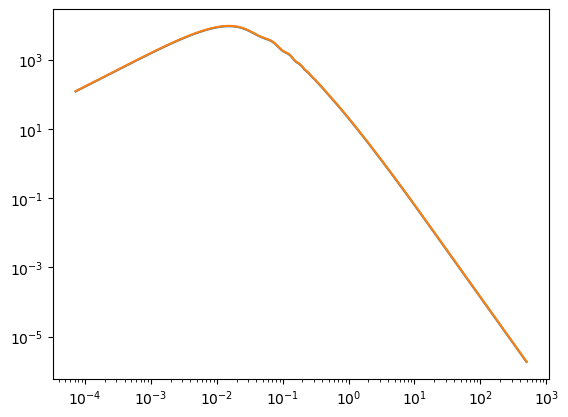

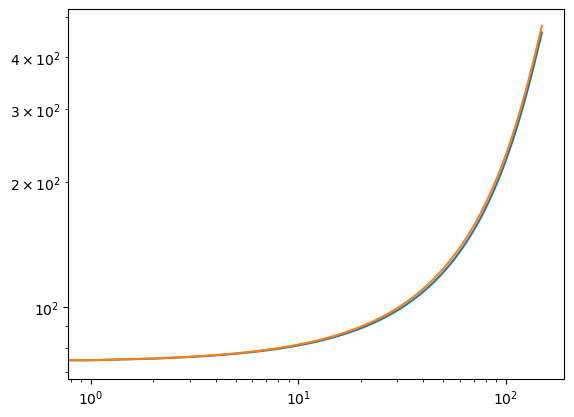

In [52]:
pm_kids = np.loadtxt("pm_lin_kids_sn.txt")
pm_test = np.loadtxt("pm_test_sn.txt")
plt.loglog(k,pm_kids[100])
plt.loglog(k,pm_test[100])
plt.show()

plt.loglog(pm_kids[::-1,0])
plt.loglog(pm_test[::-1,0])

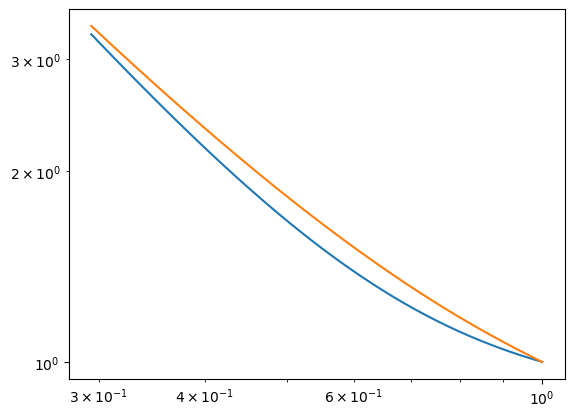

In [3]:
zz = np.linspace(0,2.4,25000)
aa = 1/(1+zz)[::-1]
lcdm = np.loadtxt("lcdm_expf.txt")
model = np.loadtxt("model_expf.txt")

plt.loglog(aa,lcdm)
plt.loglog(aa,model)

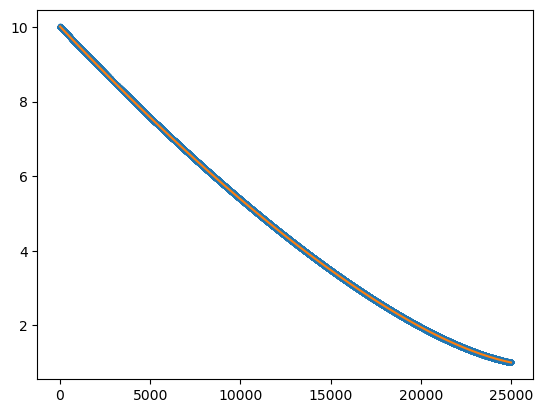

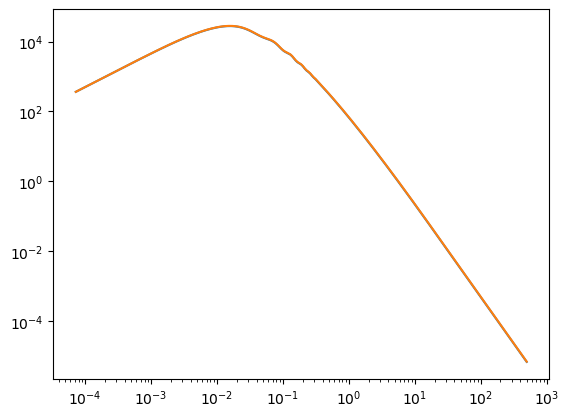

In [23]:
lcdm = np.loadtxt("lcdm_expf.txt")
model = np.loadtxt("expf.txt")
plt.plot(lcdm,marker='.')
plt.plot(model)
plt.show()

pm_kids = np.loadtxt("pm_kids_ext.txt")[0]
pm = np.loadtxt("pm_test.txt")[0]
plt.loglog(k,pm_kids)
plt.loglog(k,pm)

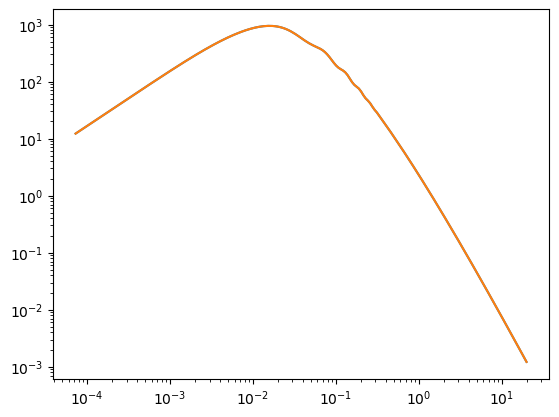

In [21]:
pm = np.loadtxt("pm.txt")[::-1][-1]
pm_kids = np.loadtxt("pm_lin_kids.txt")[-1]
plt.loglog(kpre,pm_kids)
plt.loglog(kpre,pm)

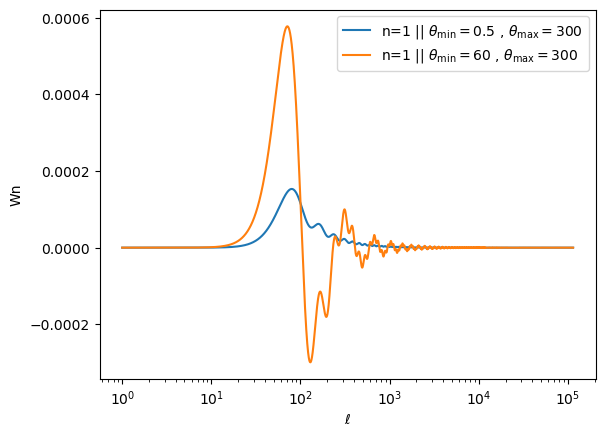

In [4]:
wn05 = np.loadtxt("WnLog1-0.50-300.00.table",skiprows=1)
wn60 = np.loadtxt("WnLog1-60.00-300.00.table",skiprows=1)

plt.semilogx(np.exp(wn05[:,0]),wn05[:,1],label=r"n=1 || $\theta_{\min}=0.5$ , $\theta_{\max}=300$")
plt.semilogx(np.exp(wn60[:,0]),wn60[:,1],label=r"n=1 || $\theta_{\min}=60$ , $\theta_{\max}=300$")
# plt.xlim(1,12)
plt.xlabel(r"$\ell$")
plt.ylabel("Wn")
plt.legend()

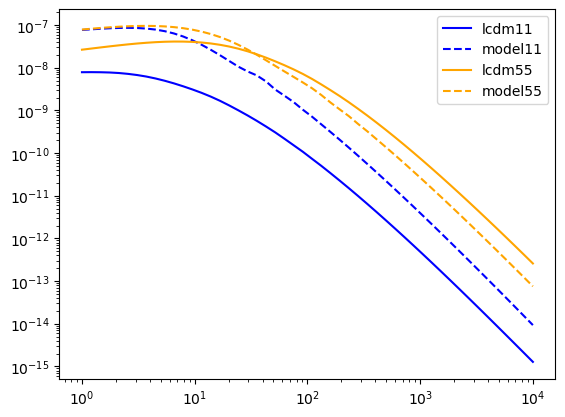

In [12]:
import numpy as np
cell_kids11 = np.loadtxt("c_ell_kids_lin.txt")
cell_qso11 = np.loadtxt("c_ell_sn_bao_qso.txt")
cell_kids55 = np.loadtxt("c_ell_kids_lin55.txt")
cell_qso55 = np.loadtxt("c_ell_sn_bao_qso55.txt")
plt.loglog(ells, cell_kids11,label="lcdm11",color="blue")
plt.loglog(ells, cell_qso11,label="model11",color="blue", ls="--")
plt.loglog(ells, cell_kids55,label="lcdm55",color="orange")
plt.loglog(ells, cell_qso55,label="model55",color="orange",ls="--")
plt.legend()

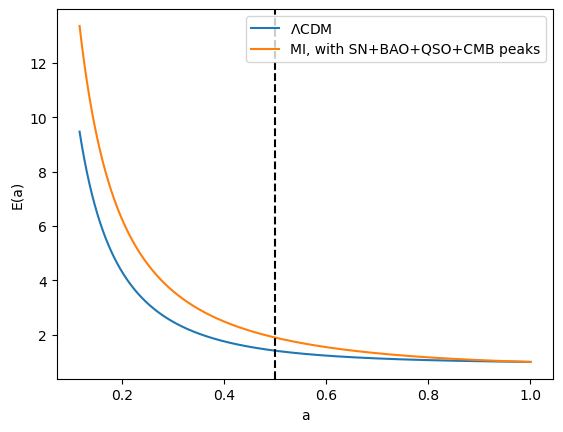

In [17]:
ahere = np.loadtxt("a_qso.txt")
expf = np.loadtxt("expf_qso.txt")
lcdm = np.loadtxt("lcdm_expf_qso.txt")
fig, ax = plt.subplots()
ax.plot(ahere,lcdm,label=r"$\Lambda$CDM")
ax.plot(ahere,expf,label="MI, with SN+BAO+QSO+CMB peaks")
ax.set_xlabel('a')
ax.set_ylabel("E(a)")
ax.axvline(0.5,0,1,color = "k", linestyle="--", clip_on = False)
ax.legend()

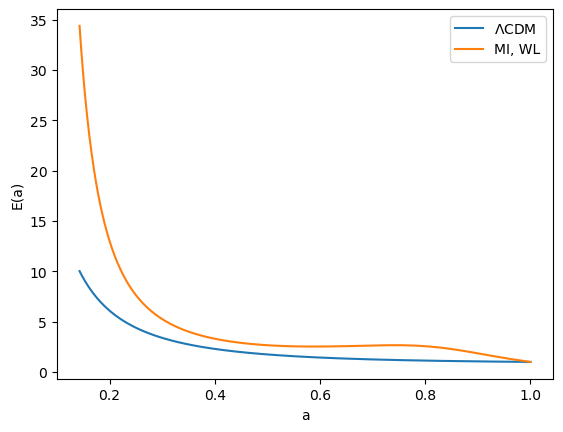

In [25]:
c = np.array([0.8437533592851256,0.031208185748578865,0.014650194204474554,-0.24940567101529854])
c = np.array([-1.4011053597380005,0.07661767557263366,0.08561481505632401,-0.3478594226011392])
error = np.array([2.6165494125527857, 0.6781386137008667,0.48766026223418657,0.8438569293804757])
min_coeffs = c - error
max_coeffs = c + error
a = np.loadtxt("a_bg.txt")
h0=0.6898
om=0.29044350092105475
n=-1
model = model_independent(c,a,h0,om,n)
plt.plot(a,model.lcdm_expf(),label=r"$\Lambda$CDM")
plt.plot(a,model.model_expf(),label="MI, WL")
# plt.plot(a,model.model_expf(c=min_coeffs),label="min")
# plt.plot(a,model.model_expf(c=max_coeffs),label="max")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.legend()
plt.savefig("weak lensing expf.pdf")

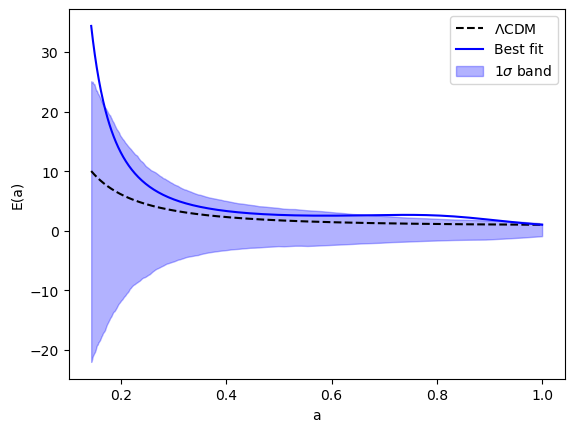

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

c = np.array([-1.4011053597380005, 0.07661767557263366,
              0.08561481505632401, -0.3478594226011392])
error = np.array([2.6165494125527857, 0.6781386137008667,
                  0.48766026223418657, 0.8438569293804757])

a = np.loadtxt("a_bg.txt")
h0 = 0.6898
om = 0.29044350092105475
n = -1

model = model_independent(c, a, h0, om, n)

# Best–fit curve
y_best = model.model_expf()

# Monte Carlo sampling of parameters within their uncertainties
Nsample = 10000
curves = []
for _ in range(Nsample):
    c_sample = np.random.normal(c, error)   # sample parameters
    curves.append(model.model_expf(c=c_sample))
curves = np.array(curves)

# Compute 1σ confidence band (16th–84th percentiles)
y_lower = np.percentile(curves, 16, axis=0)
y_upper = np.percentile(curves, 84, axis=0)

# Plot
plt.plot(a, model.lcdm_expf(), label=r"$\Lambda$CDM", c="k", ls="--")
plt.plot(a, y_best, label="Best fit", c="b")
plt.fill_between(a, y_lower, y_upper, color="b", alpha=0.3, label=r"$1\sigma$ band")

plt.xlabel("a")
plt.ylabel("E(a)")
plt.legend()
plt.savefig("weak_lensing_expf.pdf")
plt.show()


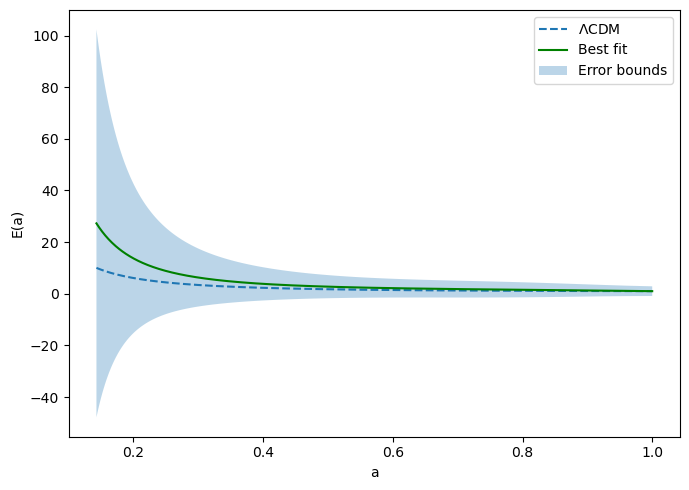

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# your numbers
c = np.array([1.4770059882545024, 0.08385879725217815,
              -0.09550484552979466, 0.09726567193865776])
error = np.array([2.5828275884640113, 0.7377970367606501,
                  0.4880022863771738, 0.5993570980288796])

a = np.loadtxt("a_bg.txt")
h0 = 0.6898
om = 0.29044350092105475
n = -1

model = model_independent(c, a, h0, om, n)

# best-fit y
y_best = model.model_expf()

# finite-difference derivatives d y / d c_i for each parameter
eps_rel = 1e-6   # small relative step
num_params = c.size
J = np.zeros((num_params, a.size))

for i in range(num_params):
    eps = eps_rel * (abs(c[i]))  # avoid zero step if c[i]==0
    c_plus = c.copy(); c_minus = c.copy()
    c_plus[i] += eps
    c_minus[i] -= eps
    y_plus = model.model_expf(c=c_plus)
    y_minus = model.model_expf(c=c_minus)
    J[i] = (y_plus - y_minus) / (2 * eps)

# assume diagonal covariance = error**2 (no parameter correlations)
var_params = error**2

# propagated variance at each a: sigma_y^2 = sum_i (J_i^2 * var_i)
sigma_y_sq = np.sum((J**2) * var_params[:, np.newaxis], axis=0)
sigma_y = np.sqrt(sigma_y_sq)

# plot
plt.figure(figsize=(7,5))
plt.plot(a, model.lcdm_expf(), label=r"$\Lambda$CDM", linestyle="--")
plt.plot(a, y_best, label="Best fit", color="green")
plt.fill_between(a, y_best - sigma_y, y_best + sigma_y, alpha=0.3,
                 label=r"Error bounds", edgecolor="none")
plt.xlabel("a")
plt.ylabel("E(a)")
# plt.ylim(0,20)
plt.legend()
plt.tight_layout()
plt.savefig("weak_lensing_expf_propagated.pdf")
plt.show()


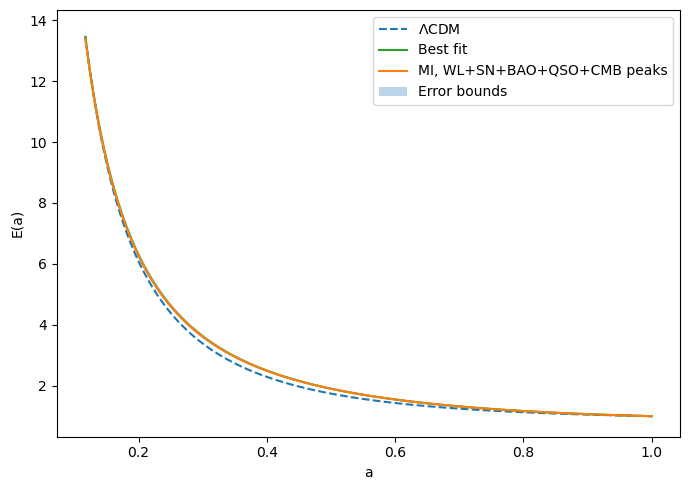

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# your numbers
c = np.array([1.05754841,-0.2245601])
c_alex = np.array([1.059,-0.2264])
error = np.array([0.01943191,0.01335506])
a = np.loadtxt("a_qso.txt")
h0 = 0.6898
om = 0.29044350092105475
n = -1

model = model_independent(c, a, h0, om, n)

# best-fit y
y_best = model.model_expf()

# finite-difference derivatives d y / d c_i for each parameter
eps_rel = 1e-6   # small relative step
num_params = c.size
J = np.zeros((num_params, a.size))

for i in range(num_params):
    eps = eps_rel * (abs(c[i]))  # avoid zero step if c[i]==0
    c_plus = c.copy(); c_minus = c.copy()
    c_plus[i] += eps
    c_minus[i] -= eps
    y_plus = model.model_expf(c=c_plus)
    y_minus = model.model_expf(c=c_minus)
    J[i] = (y_plus - y_minus) / (2 * eps)

# assume diagonal covariance = error**2 (no parameter correlations)
var_params = error**2

# propagated variance at each a: sigma_y^2 = sum_i (J_i^2 * var_i)
sigma_y_sq = np.sum((J**2) * var_params[:, np.newaxis], axis=0)
sigma_y = np.sqrt(sigma_y_sq)

# plot
plt.figure(figsize=(7,5))
plt.plot(a, model.lcdm_expf(), label=r"$\Lambda$CDM", linestyle="--")
plt.plot(a, y_best, label="Best fit", color="tab:green")
plt.plot(a,model.model_expf(c=c_alex),label="MI, WL+SN+BAO+QSO+CMB peaks")
plt.fill_between(a, y_best - sigma_y, y_best + sigma_y, alpha=0.3,
                 label=r"Error bounds", edgecolor="none")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.legend()
plt.tight_layout()
plt.savefig("joint_expf_propagated.pdf")
plt.show()


In [55]:
0.14/0.735**2

0.2591512795594429